# Galaxy Bias

`b(r, z) = sqrt( xi_gal(r, z) / xi_m(r, z) )`

The denominator is the **linear matter** correlation function from CAMB — not a halo xi. Dark matter halos are themselves biased tracers of the matter field, so using halo xi in the denominator would give b ≈ 1 everywhere (you'd be dividing two versions of essentially the same tracer catalog).

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig
from galform_analysis import compute_matter_xi, compute_galaxy_bias, avg_galaxy_bias_over_subvolumes
from galform_analysis import correlation_given_redshift_and_subvolume
from galform_analysis.config import DEFAULT_RBINS, get_snapshot_redshift

mpl.setconfig()

# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM   = 'L800'
sim   = SimulationConfig(SIM)
RBINS = DEFAULT_RBINS

## Linear matter correlation function

CAMB computes P(k, z) from the simulation cosmology; we Hankel-transform to get xi_m(r, z). The amplitude is normalised to match sigma_8 from the SimulationConfig.

In [2]:
IZ_NUM = 155
z      = get_snapshot_redshift(f'iz{IZ_NUM}', SIM) or 0.0

xi_m = compute_matter_xi(sim, z=z, rbins=RBINS)

print(f"z = {z:.4f}")
print(f"xi_m at r=1 Mpc/h: {xi_m.filter(xi_m['r'] < 2)['xi'][0]:.3f}")
print(f"Cosmology: Omega_m={sim.omega_m}, sigma_8={sim.sigma_8}, h={sim.h}")

z = 1.4955
xi_m at r=1 Mpc/h: 5.887
Cosmology: Omega_m=0.307, sigma_8=0.8288, h=0.6777


## Galaxy xi and bias for a single subvolume

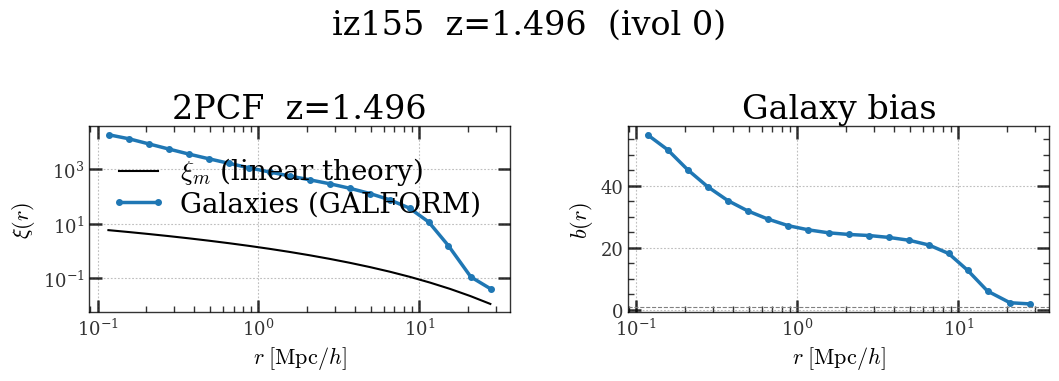

In [3]:
import os

iz_path = os.path.join(BASE_DIR, f'iz{IZ_NUM}')
xi_gal = correlation_given_redshift_and_subvolume(iz_path, ivol=0)

bias = compute_galaxy_bias(xi_gal, xi_m)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(xi_m['r'],   xi_m['xi'],   'k-',  lw=1.5, label=r'$\xi_m$ (linear theory)')
ax.plot(xi_gal['r'], xi_gal['xi'], 'C0o-', ms=4,  label='Galaxies (GALFORM)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$\xi(r)$')
ax.set_title(f'2PCF  z={z:.3f}'); ax.legend()

ax = axes[1]
ax.plot(bias['r'], bias['bias'], 'C0o-', ms=4)
ax.axhline(1, color='0.5', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$b(r)$')
ax.set_title('Galaxy bias')

fig.suptitle(f'iz{IZ_NUM}  z={z:.3f}  (ivol 0)')
fig.tight_layout(); plt.show()

## Average bias over multiple subvolumes

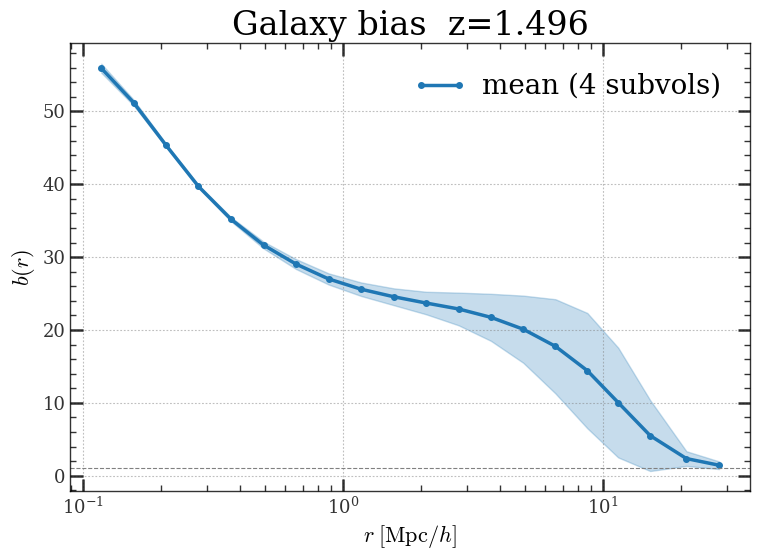

In [4]:
IVOLS = list(range(4))

xi_gal_list = [
    correlation_given_redshift_and_subvolume(iz_path, ivol=iv)
    for iv in IVOLS
]
xi_gal_list = [x for x in xi_gal_list if x is not None]

bias_avg = avg_galaxy_bias_over_subvolumes(xi_gal_list, xi_m)

fig, ax = plt.subplots()
ax.plot(bias_avg['r'], bias_avg['bias'], 'C0o-', ms=4, label=f'mean ({len(xi_gal_list)} subvols)')
ax.fill_between(
    bias_avg['r'],
    bias_avg['bias'] - bias_avg['bias_std'],
    bias_avg['bias'] + bias_avg['bias_std'],
    alpha=0.25, color='C0',
)
ax.axhline(1, color='0.5', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$b(r)$')
ax.set_title(f'Galaxy bias  z={z:.3f}')
ax.legend(); fig.tight_layout(); plt.show()

## Redshift evolution of bias

Note: `ns=1.0` for Millennium cosmology; keep `ns=0.961` (default) for L800.

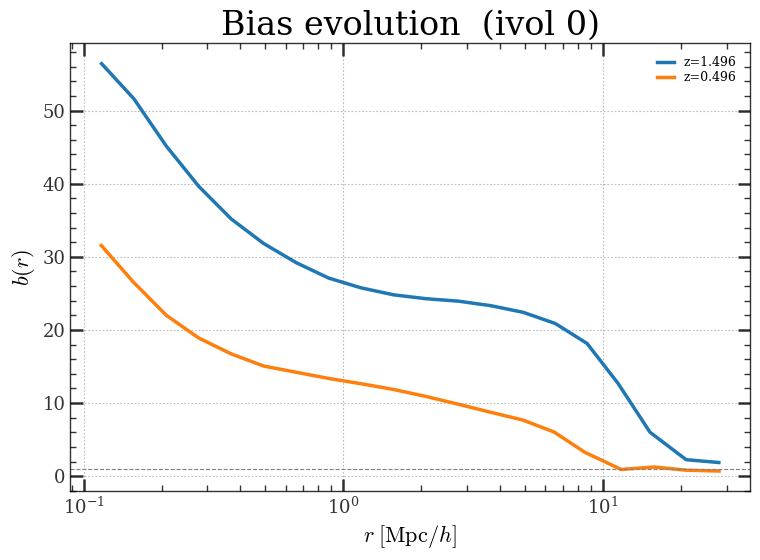

In [5]:
IZ_NUMS = [82, 120, 155, 207]

fig, ax = plt.subplots()
for iz_num in IZ_NUMS:
    z_snap = get_snapshot_redshift(f'iz{iz_num}', SIM) or 0.0
    iz_p   = os.path.join(BASE_DIR, f'iz{iz_num}')
    xi_g   = correlation_given_redshift_and_subvolume(iz_p, ivol=0)
    xi_m_z = compute_matter_xi(sim, z=z_snap, rbins=RBINS)
    if xi_g is None:
        continue
    b = compute_galaxy_bias(xi_g, xi_m_z)
    ax.plot(b['r'], b['bias'], label=f'z={z_snap:.3f}')

ax.axhline(1, color='0.5', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$b(r)$')
ax.set_title('Bias evolution  (ivol 0)')
ax.legend(fontsize=9); fig.tight_layout(); plt.show()